# Tirex Training

In [1]:
import sys
sys.path.append('../tirex/src') # Add the path to the tirex module

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from datetime import datetime
from pathlib import Path

from tirex import ForecastModel, load_model
from tirex.util import plot_forecast

# set default figure size for all plots
plt.rcParams["figure.figsize"] = (12, 6)
# set default seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load data

Download the data from the notebook [data_download.ipynb](data_download.ipynb) before.

In [3]:
data_path_train = "../data/train.csv"
data_path_test = "../data/test.csv"

data_train = pl.read_csv(data_path_train, try_parse_dates=True)
data_test = pl.read_csv(data_path_test, try_parse_dates=True)

number_series_train = len(data_train['series_index'].unique())
number_series_test = len(data_test['series_index'].unique())

print(f"Number of time series in the train set: {number_series_train} | Length of the train set: {len(data_train)}")
print(f"Number of time series in the test set: {number_series_test} | Length of the test set: {len(data_test)}")
data_test.head()

Number of time series in the train set: 361 | Length of the train set: 20266216
Number of time series in the test set: 361 | Length of the test set: 5066729


timestamp,value,series_name,series_index
datetime[μs],f64,str,i64
2025-09-27 22:00:00,0.564,"""home_electricity""",0
2025-09-27 22:15:00,0.564,"""home_electricity""",0
2025-09-27 22:30:00,0.556,"""home_electricity""",0
2025-09-27 22:45:00,0.568,"""home_electricity""",0
2025-09-27 23:00:00,0.56,"""home_electricity""",0


In [4]:
# reduce amount of data
amount_train = 0.10
amount_test = 0.10

series_idx_train = data_train['series_index'].unique()
number_series_train = len(series_idx_train)
number_series_train_final = int(number_series_train * amount_train)
data_train_sampled = data_train.filter(pl.col('series_index').is_in(series_idx_train.sample(number_series_train_final).implode()))

series_idx_test = data_test['series_index'].unique()
number_series_test = len(series_idx_test)
number_series_test_final = int(number_series_test * amount_test)
data_test_sampled = data_test.filter(pl.col('series_index').is_in(series_idx_test.sample(number_series_test_final).implode()))

print(f"Training on {number_series_train_final} out of {number_series_train} series.")
print(f"Testing on {number_series_test_final} out of {number_series_test} series.")

Training on 36 out of 361 series.
Testing on 36 out of 361 series.


## Fine-Tuning Data

In [5]:
data_path_fets = "../data/data_fets.csv"
data_fets = pl.read_csv(data_path_fets, try_parse_dates=True)
data_fets

timestamp,value,series_index
"datetime[μs, UTC]",f64,i64
2019-12-31 23:00:00 UTC,43881.8,0
2019-12-31 23:15:00 UTC,43639.6,0
2019-12-31 23:30:00 UTC,43330.9,0
2019-12-31 23:45:00 UTC,43149.5,0
2020-01-01 00:00:00 UTC,43017.3,0
…,…,…
2025-10-13 20:45:00 UTC,51524.0,0
2025-10-13 21:00:00 UTC,50427.2,0
2025-10-13 21:15:00 UTC,49845.8,0


# Load Model

In [6]:
model: ForecastModel = load_model("NX-AI/TiRex")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Model device: {device}")

Total Parameters: 35,291,200
Model device: cuda


In [7]:
# for restoring the original behavior of the model after our modifications
from tirex import TiRexZero

TiRexZero._original_forecast_tensor = TiRexZero._forecast_tensor

def restore_original_behavior():
    if hasattr(TiRexZero, '_original_forecast_tensor'):
        TiRexZero._forecast_tensor = TiRexZero._original_forecast_tensor
        print("Restored original NaN-filling behavior.")
    else:
        print("Original method backup not found.")

# Dataloader

Dataloader produces sequences of length $n$ for the input and target sequences with random predictions lengths in the range of $s_{\min}$ and $s_{\max}$.

In [8]:
from tirex_loss.dataloader import build_dataloader, build_dataloader_from_dataset, TirexDataset
from tirex_loss.dataloader.utils import create_windows

In [9]:
n = model.config.train_ctx_len
s_min = 32
s_max = 128
batch_size = 8

dataloader_train = build_dataloader(data_train_sampled,
                                    context_length=n,
                                    s_min=s_min,
                                    s_max=s_max,
                                    batch_size=batch_size,
                                    shuffle=True,
                                    num_workers=0,
                                    pin_memory=True
                                    )
dataloader_test = build_dataloader(data_test_sampled,
                                   context_length=n,
                                   s_min=s_min,
                                   s_max=s_max,
                                   batch_size=batch_size,
                                   shuffle=False,
                                   num_workers=0,
                                   pin_memory=True
                                   )

len(dataloader_train), len(dataloader_test)

(3037, 614)

## Fine-Tuning data

In [10]:
n = model.config.train_ctx_len
s_min = 32
s_max = 128
batch_size = 8
train_ratio = 0.8

data_fets_filtered = data_fets
seq, lengths = create_windows(data_fets_filtered, n=n, s_min=s_min, s_max=s_max)

idx = np.random.permutation(len(seq))
seq, lengths = seq[idx], lengths[idx]

split = int(len(seq) * train_ratio)
seq_train, seq_test = seq[:split], seq[split:]
lengths_train, lengths_test = lengths[:split], lengths[split:]

dataset_train = TirexDataset(sequences=seq_train,
                             prediction_lengths=lengths_train,
                             context_length=n,
                             prediction_length_min=s_min,
                             prediction_length_max=s_max
                             )
dataset_test = TirexDataset(sequences=seq_test,
                            prediction_lengths=lengths_test,
                            context_length=n,
                            prediction_length_min=s_min,
                            prediction_length_max=s_max
                            )

dataloader_train = build_dataloader_from_dataset(dataset_train,
                                    batch_size=batch_size,
                                    shuffle=True,
                                    num_workers=0,
                                    pin_memory=True
                                    )
dataloader_test = build_dataloader_from_dataset(dataset_test,
                                   batch_size=batch_size,
                                   shuffle=False,
                                   num_workers=0,
                                   pin_memory=True
                                   )

len(dataloader_train), len(dataloader_test)

(250, 61)

# Training / Fine-Tuning

In [11]:
from tirex_loss.training.tirex_trainer import Tirex_Trainer
from tirex_loss.loss import QuantileLoss

## Original Behavior

In [12]:
# Hyperparameters
epochs = 15
early_stop_patience = 100
lr = 1e-4
weight_decay = 1e-5
use_gradient_clipping = False
clipping_max_norm = 1.0
criterion = QuantileLoss(model.config.quantiles).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# Logging and model saving paths
prefix = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = Path("../models") / f"tirex_original_{prefix}"
log_path = model_path

model_path.mkdir(parents=True, exist_ok=True)
log_path.mkdir(parents=True, exist_ok=True)

# Trainer
trainer =Tirex_Trainer(model,
              criterion=criterion,
              optimizer=optimizer,
              model_path=str(model_path),
              log_path=str(log_path)
              )

In [13]:
trainer.train(dataloader_train, dataloader_test,
                batch_size=batch_size,
                num_epochs=epochs,
                early_stop_patience=early_stop_patience,
                use_clipping=use_gradient_clipping,
                clipping_max_norm=clipping_max_norm
                )

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Batches Train:   0%|          | 0/250 [00:00<?, ?it/s]

Batches Test:   0%|          | 0/61 [00:00<?, ?it/s]

Batches Train:   0%|          | 0/250 [00:00<?, ?it/s]

Batches Test:   0%|          | 0/61 [00:00<?, ?it/s]

...

Batches Test:   0%|          | 0/61 [00:00<?, ?it/s]

Batches Train:   0%|          | 0/250 [00:00<?, ?it/s]

Batches Test:   0%|          | 0/61 [00:00<?, ?it/s]

Batches Train:   0%|          | 0/250 [00:00<?, ?it/s]

Batches Test:   0%|          | 0/61 [00:00<?, ?it/s]

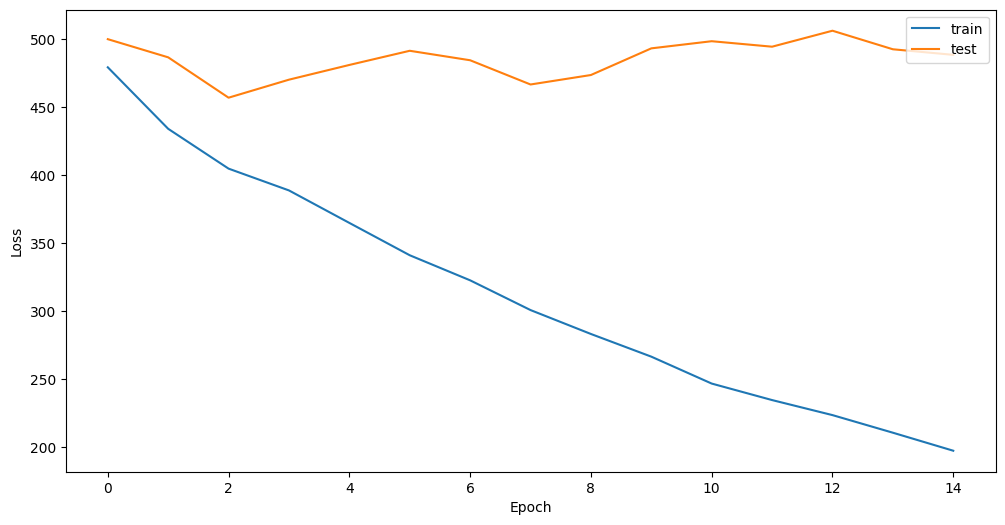

In [17]:
fig_loss = trainer.plot_loss(log_lr=False)
fig_loss.savefig(str(model_path / "training_loss_curve.png"), dpi=300, bbox_inches="tight")

In [15]:
# load best model
dict_path = model_path / "best_model.pth"
state_dict = torch.load(dict_path, weights_only=True)
model.load_state_dict(state_dict)

<All keys matched successfully>

## Autoregressive Behavior

In [ ]:
# monkey patch the model to use the autoregressive mean forecast tensor instead of filling with NaNs
from tirex_loss.modifications.autoregressive import autoregressive_mean_forecast_tensor
TiRexZero._forecast_tensor = autoregressive_mean_forecast_tensor

In [ ]:
# Hyperparameters
epochs = 15
early_stop_patience = 100
lr = 1e-4
weight_decay = 1e-5
use_gradient_clipping = False
clipping_max_norm = 1.0
criterion = QuantileLoss(model.config.quantiles).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# Logging and model saving paths
prefix = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = Path("../models") / f"tirex_autoregressive_{prefix}"
log_path = model_path

model_path.mkdir(parents=True, exist_ok=True)
log_path.mkdir(parents=True, exist_ok=True)

# Trainer
trainer =Tirex_Trainer(model,
              criterion=criterion,
              optimizer=optimizer,
              model_path=str(model_path),
              log_path=str(log_path)
              )

In [ ]:
trainer.train(dataloader_train, dataloader_test,
                batch_size=batch_size,
                num_epochs=epochs,
                early_stop_patience=early_stop_patience,
                use_clipping=use_gradient_clipping,
                clipping_max_norm=clipping_max_norm
                )

In [ ]:
fig_loss = trainer.plot_loss(log_lr=False)
fig_loss.savefig(str(model_path / "training_loss_curve.png"), dpi=300, bbox_inches="tight")

In [ ]:
# load best model
dict_path = model_path / "best_model.pth"
state_dict = torch.load(dict_path, weights_only=True)
model.load_state_dict(state_dict)